<a href="https://colab.research.google.com/github/Magnolia-Liu/Medsort/blob/main/MedSort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning and Augmentation:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Crop individual objects from YOLO format bounding boxes from Medbin dataset

In [ ]:
import os
import cv2

image_dir = "/content/drive/MyDrive/medbin_yolo/train/images"
label_dir = "/content/drive/MyDrive/medbin_yolo/train/labels"
output_dir = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train"
os.makedirs(output_dir, exist_ok=True)

def boxes_overlap(box1, box2, iou_thresh=0.1):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)
    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h
    if inter_area == 0:
        return False
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    iou = inter_area / (area1 + area2 - inter_area)
    return iou > iou_thresh


for label_file in os.listdir(label_dir):
    if not label_file.endswith(".txt"):
        continue

    img_name = label_file.replace(".txt", ".jpg")
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    with open(os.path.join(label_dir, label_file), "r") as f:
        lines = [line.strip().split() for line in f.readlines()]

    boxes = []
    for line in lines:
        cls = line[0]
        coords = list(map(float, line[1:]))
        xs = coords[0::2]
        ys = coords[1::2]
        xs = [int(x * w) for x in xs]
        ys = [int(y * h) for y in ys]
        x_min, x_max = max(min(xs), 0), min(max(xs), w)
        y_min, y_max = max(min(ys), 0), min(max(ys), h)
        boxes.append((cls, (x_min, y_min, x_max, y_max)))

    valid_boxes = []
    for i, (cls_i, box_i) in enumerate(boxes):
        overlaps = False
        for j, (cls_j, box_j) in enumerate(boxes):
            if i != j and boxes_overlap(box_i, box_j):
                overlaps = True
                break
        if not overlaps:
            valid_boxes.append((cls_i, box_i))

    for cls, (x_min, y_min, x_max, y_max) in valid_boxes:
        crop = img[y_min:y_max, x_min:x_max]
        if crop.size == 0:
            continue

        # Make class folder
        class_folder = os.path.join(output_dir, f"class_{cls}")
        os.makedirs(class_folder, exist_ok=True)

        out_name = f"{img_name[:-4]}_{x_min}_{y_min}.jpg"
        cv2.imwrite(os.path.join(class_folder, out_name), crop)


KeyboardInterrupt: 

In [ ]:
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total cropped images train: {count}")

Total cropped images train: 12253


In [ ]:
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total cropped images val: {count}")

Total cropped images val: 974


In [ ]:
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total cropped images test2: {count}")

Total cropped images test2: 150


After Manually Sorting and Quality Checking Images:

In [ ]:
output_dir = "/content/drive/MyDrive/aps360_project_dataset/train/sharp"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total sharp images: {count}")
num_sharp = count

Total sharp images: 3214


In [ ]:
output_dir = "/content/drive/MyDrive/aps360_project_dataset/train/general"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total general images: {count}")
num_general = count

Total general images: 2323


In [ ]:
output_dir = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_val"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total general images: {count}")

Add padding to crops so images are 224x224

In [ ]:
import cv2
import numpy as np
import random

def pad_to_square_random_position(img, size=224, min_scale=0.5, max_scale=0.9):
    h, w = img.shape[:2]
    scale_factor = random.uniform(min_scale, max_scale)
    target_dim = int(size * scale_factor)

    # Resize crop keeping aspect ratio
    scale = target_dim / max(h, w)
    resized = cv2.resize(img, (int(w*scale), int(h*scale)))

    # Random neutral color (mid-gray to beige range)
    color = random.randint(100, 180)
    background = np.full((size, size, 3), color, dtype=np.uint8)

    # Random position for the resized object
    max_y = size - resized.shape[0]
    max_x = size - resized.shape[1]
    y_offset = random.randint(0, max_y)
    x_offset = random.randint(0, max_x)

    # Paste resized crop into background
    background[y_offset:y_offset+resized.shape[0], x_offset:x_offset+resized.shape[1]] = resized

    return background


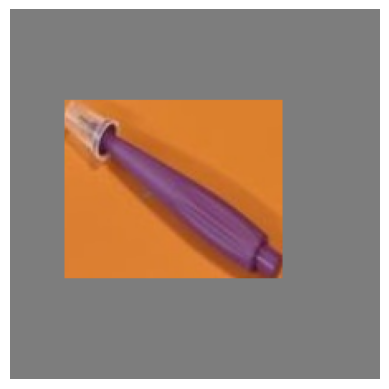

In [ ]:
# @title
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os

path_to_crop = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/sharp/class_16/1714885629283_jpg.rf.4cf32cee11e45bfdb40e347b1f608857_150_265.jpg"
output_dir = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/test"
os.makedirs(output_dir, exist_ok=True) # Ensure the output directory exists

img = cv2.imread(path_to_crop)
padded = pad_to_square_random_position(img, size=224)

# Construct the output file path with a .jpg extension
output_path = os.path.join(output_dir, "padded_image.jpg")
cv2.imwrite(output_path, padded)

padded_rgb = cv2.cvtColor(padded, cv2.COLOR_BGR2RGB)

plt.imshow(padded_rgb)
plt.axis('off')
plt.show()

In [ ]:
from tqdm import tqdm
def process_folder(input_root, output_root, size=224):
    """Recursively process all images in input_root and save to output_root."""
    for root, dirs, files in os.walk(input_root):
        # Recreate the subfolder structure in output_root
        rel_path = os.path.relpath(root, input_root)
        output_dir = os.path.join(output_root, rel_path)
        os.makedirs(output_dir, exist_ok=True)

        # Filter for image files
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for filename in tqdm(image_files, desc=f"Processing {rel_path}", leave=False):
            input_path = os.path.join(root, filename)
            output_path = os.path.join(output_dir, filename)

            img = cv2.imread(input_path)
            if img is None:
                continue  # skip unreadable files

            padded = pad_to_square_random_position(img, size=size)
            cv2.imwrite(output_path, padded)

In [ ]:
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/sharp"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/train/sharp"
process_folder(input_folder, output_folder, size=224)

In [ ]:
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/hazardous"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/train/hazardous"
process_folder(input_folder, output_folder, size=224)

In [ ]:
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/general"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/train/general"
process_folder(input_folder, output_folder, size=224)

validation split

In [ ]:
# @title
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_val/sharp"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/val/sharp"
process_folder(input_folder, output_folder, size=224)

output_dir = "/content/drive/MyDrive/aps360_project_dataset/val/sharp"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total sharp images: {count}")

Total sharp images: 149


In [ ]:
# @title
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_val/hazardous"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/val/hazardous"
process_folder(input_folder, output_folder, size=224)

output_dir = "/content/drive/MyDrive/aps360_project_dataset/val/hazardous"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total hazardous images: {count}")

NameError: name 'process_folder' is not defined

In [ ]:
# @title
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_val/general"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/val/general"
process_folder(input_folder, output_folder, size=224)


output_dir = "/content/drive/MyDrive/aps360_project_dataset/val/general"
count = sum(len(files) for _, _, files in os.walk(output_dir))
print(f"Total general images: {count}")

Add ~100 images of sharps from Trashbox dataset, augment so ~1000 extra images for sharps category

In [ ]:
# @title
import os
import random
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from tqdm import tqdm

# Paths
input_dir = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/sharp/trashbox_sharps"
output_dir = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/sharp/trashbox_sharps_aug"    # where to save augmented images
os.makedirs(output_dir, exist_ok=True)

# Number of augmentations per image
num_aug_per_image = 10

def augment_image(img):
    """Apply one random augmentation combination."""
    # Random horizontal flip
    if random.random() < 0.5:
        img = ImageOps.mirror(img)

    # Random rotation (-20° to 20°)
    if random.random() < 0.8:
        angle = random.uniform(-20, 20)
        img = img.rotate(angle, resample=Image.BICUBIC, expand=True, fillcolor=(0, 0, 0))

    # Random color jitter (brightness, contrast, saturation)
    if random.random() < 0.8:
        enhancers = [
            (ImageEnhance.Brightness, 0.8, 1.2),
            (ImageEnhance.Contrast, 0.8, 1.2),
            (ImageEnhance.Color, 0.8, 1.2)
        ]
        for enhancer, lo, hi in enhancers:
            factor = random.uniform(lo, hi)
            img = enhancer(img).enhance(factor)

    # Slight Gaussian blur
    if random.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 1.2)))

    # Random crop & resize back
    if random.random() < 0.5:
        w, h = img.size
        scale = random.uniform(0.8, 1.0)
        new_w, new_h = int(w * scale), int(h * scale)
        left = random.randint(0, w - new_w)
        top = random.randint(0, h - new_h)
        img = img.crop((left, top, left + new_w, top + new_h))
        img = img.resize((w, h), Image.BICUBIC)

    # Random noise (light)
    if random.random() < 0.2:
        import numpy as np
        np_img = np.array(img).astype('float32')
        noise = np.random.normal(0, 8, np_img.shape)
        np_img = np.clip(np_img + noise, 0, 255).astype('uint8')
        img = Image.fromarray(np_img)

    return img


# Main loop
for filename in tqdm(os.listdir(input_dir)):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    img_path = os.path.join(input_dir, filename)
    img = Image.open(img_path).convert("RGB")

    basename = os.path.splitext(filename)[0]
    for i in range(num_aug_per_image):
        aug_img = augment_image(img)
        aug_name = f"{basename}_aug{i+1}.jpg"
        aug_img.save(os.path.join(output_dir, aug_name), quality=95)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/sharp/trashbox_sharps'

In [ ]:
import os
input_folder = "/content/drive/MyDrive/aps360_project_dataset/medbinyolo_train/trashbox_sharps_aug"
output_folder = "/content/drive/MyDrive/aps360_project_dataset/train"
process_folder(input_folder, output_folder, size=224)

In [ ]:
import os
import shutil

root_dir = "/content/drive/MyDrive/aps360_project_dataset/val"

for main_class in os.listdir(root_dir):
    class_path = os.path.join(root_dir, main_class)
    if not os.path.isdir(class_path):
        continue

    for subdir, _, files in os.walk(class_path):
        if subdir == class_path:
            continue
        for file in files:
            src = os.path.join(subdir, file)
            dst = os.path.join(class_path, file)
            # Avoid overwriting files with same name
            if os.path.exists(dst):
                base, ext = os.path.splitext(file)
                dst = os.path.join(class_path, f"{base}_dup{ext}")
            shutil.move(src, dst)


# Base Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt # for plotting
import torch.optim as optim #for gradient descent

torch.manual_seed(1) # set the random seed
from torchvision import datasets, transforms

In [ ]:
train_data = datasets.ImageFolder("/content/drive/MyDrive/aps360_project_dataset/train", transform=transforms.ToTensor())

val_data = datasets.ImageFolder("/content/drive/MyDrive/aps360_project_dataset/val", transform=transforms.ToTensor())

In [ ]:
print(train_data.classes)
print(val_data.classes)


['general', 'hazardous', 'sharp']
['general', 'hazardous', 'sharp']


In [ ]:
test_data = datasets.ImageFolder("/content/drive/MyDrive/aps360_project_dataset/test", transform=transforms.ToTensor())

In [ ]:
class Base_Model(nn.Module):
    def __init__(self, name = "Base_Model", kernel_size=5):
        super(Base_Model, self).__init__()
        self.name = name
        self.conv1 = nn.Conv2d(3, 5, kernel_size)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, kernel_size)

        conv_output_size = ((224 - kernel_size + 1) // 2 - kernel_size + 1) // 2
        self.fc1 = nn.Linear(10 * conv_output_size * conv_output_size, 32)
        self.fc2 = nn.Linear(32, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Training Script:

In [ ]:
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

In [ ]:
def get_accuracy(model, train_data, val_data, train=False):
    if train:
        data = train_data
    else:
        data = val_data

    correct = 0
    total = 0
    # Get the device from the model
    device = next(model.parameters()).device
    with torch.no_grad():
      for imgs, labels in torch.utils.data.DataLoader(data, batch_size=64):
          # Move data to the same device as the model
          imgs, labels = imgs.to(device), labels.to(device)

          output = model(imgs)

          #select index with maximum prediction score
          pred = output.max(1, keepdim=True)[1]
          correct += pred.eq(labels.view_as(pred)).sum().item()
          total += imgs.shape[0]
    return correct / total

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

def train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = model.to(device)
    counts = torch.tensor([num_general, num_hazardous, num_sharp], dtype=torch.float)
    #class_weights = 1. / torch.tensor(counts, dtype=torch.float)
    #sample_weights = [class_weights[label] for _, label in train_data.samples]
    #sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    #train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, num_workers=2, sampler=sampler)

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)

    weights = 1.0 / counts            # inverse frequency
    weights = weights / weights.sum() # optional normalization
    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    val_epoch_losses = []
    val_acc = []
    epoch_losses = []
    train_acc = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        val_running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)

        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            loss = criterion(out, labels)

            val_running_loss += loss.item() * imgs.size(0)

        val_avg_loss = val_running_loss / len(train_loader.dataset)
        val_epoch_losses.append(val_avg_loss)

        model.eval()
        with torch.no_grad():
            train_accuracy = get_accuracy(model, train_data, val_data, train=True)
            val_accuracy = get_accuracy(model, train_data, val_data, train=False)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        # Save checkpoint
        model_path = get_model_name("Primary_Model", batch_size, learning_rate, epoch)
        torch.save(model.state_dict(), model_path)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_loss:.4f} | "
              f"Val Loss: {val_avg_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | "
              f"Val Acc: {val_accuracy:.4f}")

    # --- Plotting Section ---
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss per Epoch")
    plt.plot(epochs, epoch_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_epoch_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Accuracy per Epoch")
    plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
    plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")


Trainer that switches optimizers

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

def train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = model.to(device)
    counts = torch.tensor([num_general, num_hazardous, num_sharp], dtype=torch.float)
    #class_weights = 1. / torch.tensor(counts, dtype=torch.float)
    #sample_weights = [class_weights[label] for _, label in train_data.samples]
    #sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    #train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, num_workers=2, sampler=sampler)

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True, num_workers=2)
    weights = 1.0 / counts            # inverse frequency
    weights = weights / weights.sum() # optional normalization
    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    val_epoch_losses = []
    val_acc = []
    epoch_losses = []
    train_acc = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        val_running_loss = 0.0
        if epoch == 10:
            optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)

        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            loss = criterion(out, labels)

            val_running_loss += loss.item() * imgs.size(0)

        val_avg_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_losses.append(val_avg_loss)

        model.eval()
        with torch.no_grad():
            train_accuracy = get_accuracy(model, train_data, val_data, train=True)
            val_accuracy = get_accuracy(model, train_data, val_data, train=False)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        # Save checkpoint
        model_path = get_model_name("Primary_Model", batch_size, learning_rate, epoch)
        torch.save(model.state_dict(), model_path)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_loss:.4f} | "
              f"Val Loss: {val_avg_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | "
              f"Val Acc: {val_accuracy:.4f}")

    # --- Plotting Section ---
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss per Epoch")
    plt.plot(epochs, epoch_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_epoch_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Accuracy per Epoch")
    plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
    plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")


Check If Base Model Can Overfit to Small Subset of Data:

In [ ]:
import torch
from torch.utils.data import Subset
import numpy as np

# Take first 50 samples for small training set
indices = np.random.choice(len(train_data), size=50, replace=False)
small_train = Subset(train_data, indices)

# Small validation set
val_indices = np.random.choice(len(val_data), size=10, replace=False)
small_val = Subset(val_data, val_indices)


In [ ]:

model = Base_Model()
print(model)
train(model,train_data= small_train, val_data= small_val, batch_size=50, learning_rate=0.001, num_epochs=50)


Base_Model(
  (conv1): Conv2d(3, 5, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(5, 10, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=28090, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)


NameError: name 'small_train' is not defined

Train Base Model:

In [ ]:
# @title
sharp_accuracy = get_accuracy(model2, sharp_val, sharp_val, train=False)
print(sharp_accuracy)
hazardous_accuracy = get_accuracy(model2, hazardous_val, hazardous_val, train=False)
print(hazardous_accuracy)
general_accuracy = get_accuracy(model2, general_val, general_val, train=False)
print(general_accuracy)

0.026845637583892617
0.07578558225508318
0.15609756097560976


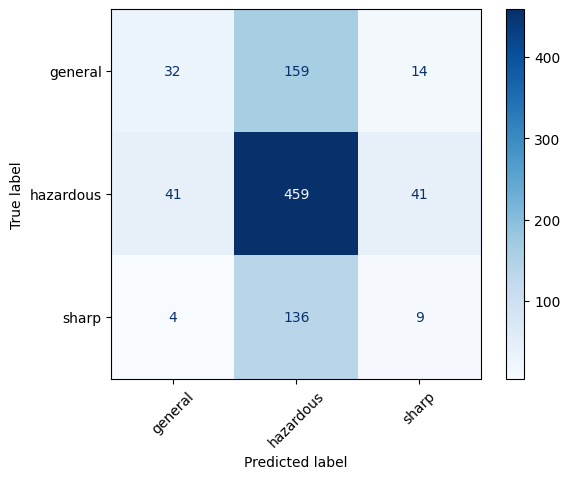

In [ ]:
# @title
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

batch_size = 64
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
model2.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model2(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

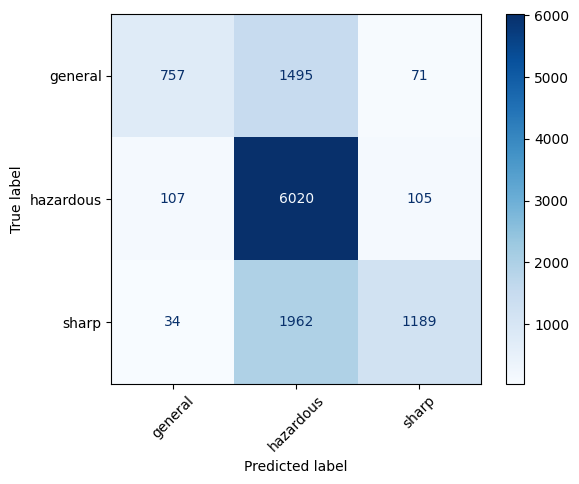

In [ ]:
# @title
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
model2.eval()
with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model2(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

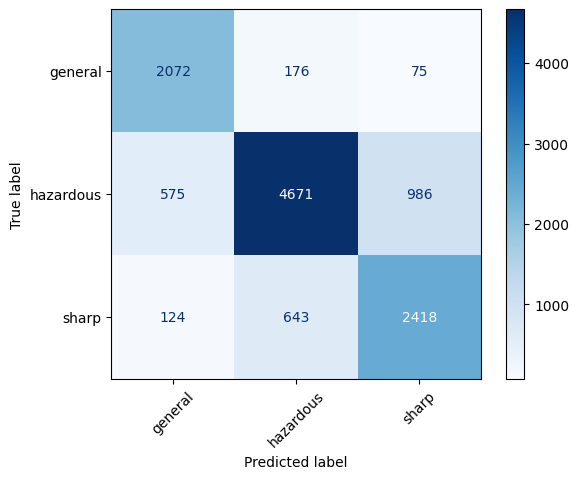

In [ ]:
# @title
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
basemodel2.eval()
with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = basemodel2(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

# Primary Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Primary_Model(nn.Module):
    def __init__(self, name="Primary_Model", kernel_size=5):
        super(Primary_Model, self).__init__()
        self.name = name

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Dropout(0.3)  # Regularization
        )


        self.avgpool = nn.AvgPool2d(28)

        # Classifier head
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

class Primary_Model(nn.Module):
    def __init__(self, name="Primary_Model", kernel_size=3):
        super(Primary_Model, self).__init__()
        self.name = name

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Dropout(0.2)  # Regularization
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


Check if model can overfit to small subset of data:

Primary_Model(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dr

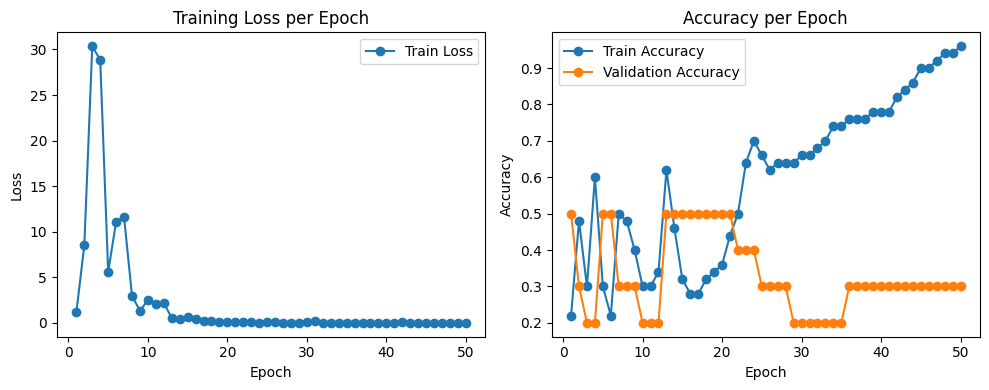

Final Training Accuracy: 0.9600
Final Validation Accuracy: 0.3000


In [ ]:

model = Primary_Model()
print(model)
train(model,train_data= small_train, val_data= small_val, batch_size=50, learning_rate=0.001, num_epochs=50)


Training on: cuda
Epoch [1/10] Loss: 0.9851 | Train Acc: 0.5310 | Val Acc: 0.6045
Epoch [2/10] Loss: 0.9277 | Train Acc: 0.5309 | Val Acc: 0.6056
Epoch [3/10] Loss: 1.2167 | Train Acc: 0.5310 | Val Acc: 0.6045
Epoch [4/10] Loss: 1.0345 | Train Acc: 0.5309 | Val Acc: 0.6045
Epoch [5/10] Loss: 1.0769 | Train Acc: 0.5308 | Val Acc: 0.6056
Epoch [6/10] Loss: 1.0011 | Train Acc: 0.5308 | Val Acc: 0.6045
Epoch [7/10] Loss: 0.8959 | Train Acc: 0.5308 | Val Acc: 0.6045
Epoch [8/10] Loss: 1.1426 | Train Acc: 0.5309 | Val Acc: 0.6045
Epoch [9/10] Loss: 1.0926 | Train Acc: 0.5307 | Val Acc: 0.6045
Epoch [10/10] Loss: 0.9595 | Train Acc: 0.5307 | Val Acc: 0.6022


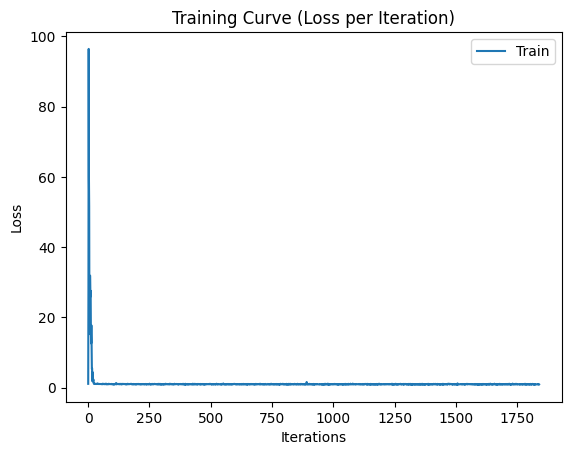

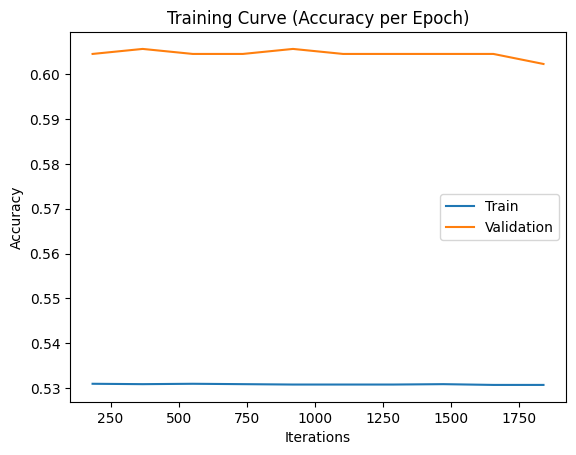

Final Training Accuracy: 0.5307
Final Validation Accuracy: 0.6022


In [ ]:
# @title
model3 = Primary_Model(kernel_size=3)
train(model3, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.002, num_epochs=10)

12/01/2025

model 1: SGD to Adam, small learning rate, inverse class weights

Training on: cuda
Epoch [1/20] Train Loss: 1.1076 | Val Loss: 0.0847 | Train Acc: 0.3038 | Val Acc: 0.2324
Epoch [2/20] Train Loss: 1.0976 | Val Loss: 0.0853 | Train Acc: 0.3326 | Val Acc: 0.2771
Epoch [3/20] Train Loss: 1.0937 | Val Loss: 0.0848 | Train Acc: 0.3548 | Val Acc: 0.3173
Epoch [4/20] Train Loss: 1.0881 | Val Loss: 0.0848 | Train Acc: 0.3716 | Val Acc: 0.3385
Epoch [5/20] Train Loss: 1.0824 | Val Loss: 0.0843 | Train Acc: 0.3962 | Val Acc: 0.3631
Epoch [6/20] Train Loss: 1.0805 | Val Loss: 0.0846 | Train Acc: 0.4042 | Val Acc: 0.3799
Epoch [7/20] Train Loss: 1.0735 | Val Loss: 0.0842 | Train Acc: 0.4221 | Val Acc: 0.4045
Epoch [8/20] Train Loss: 1.0704 | Val Loss: 0.0837 | Train Acc: 0.4266 | Val Acc: 0.4089
Epoch [9/20] Train Loss: 1.0690 | Val Loss: 0.0842 | Train Acc: 0.4349 | Val Acc: 0.4134
Epoch [10/20] Train Loss: 1.0677 | Val Loss: 0.0843 | Train Acc: 0.4456 | Val Acc: 0.4268
Epoch [11/20] Train Loss: 0.9792 | Val Loss: 0.0801 | Train Acc: 0.4477 | Val Acc: 0.3553
E

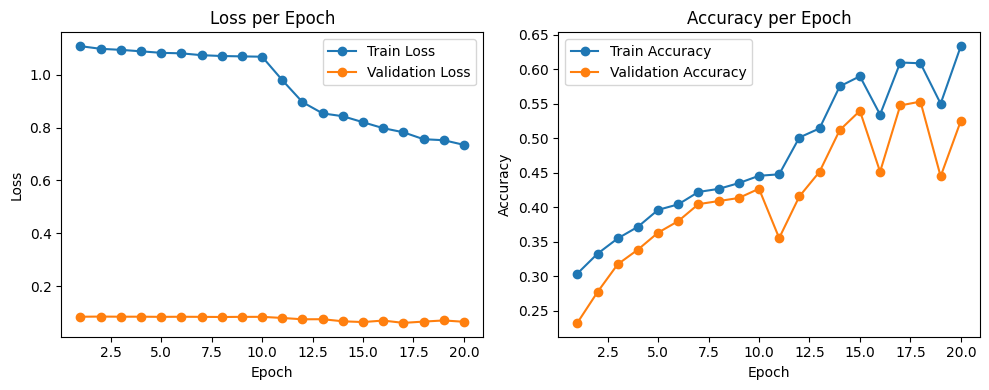

Final Training Accuracy: 0.6334
Final Validation Accuracy: 0.5251


In [ ]:
primarymodel = Primary_Model(kernel_size=3)
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.001, num_epochs=20)

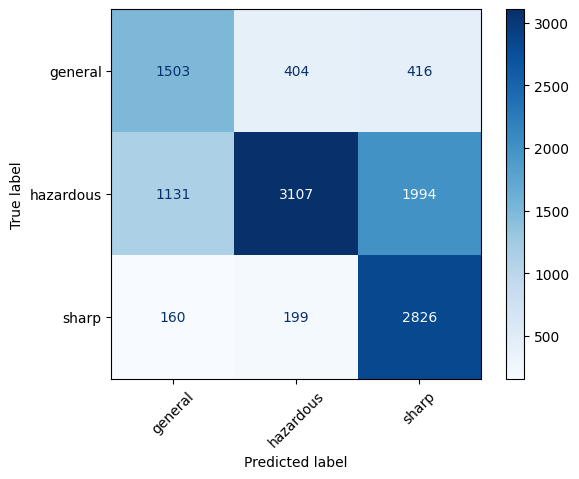

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# @title
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.001_epoch19"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
primarymodel.eval()
with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = primarymodel(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

def train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = model.to(device)
    counts = torch.tensor([num_general, num_hazardous, num_sharp], dtype=torch.float)
    #class_weights = 1. / torch.tensor(counts, dtype=torch.float)
    #sample_weights = [class_weights[label] for _, label in train_data.samples]
    #sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    #train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, num_workers=2, sampler=sampler)

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True, num_workers=2)
    # Adaptive class weights: Effective number of samples
    beta = 0.999
    effective_num = 1.0 - beta**counts
    weights = (1.0 - beta) / effective_num

    # Normalize to sum to number of classes (optional but recommended)
    weights = weights / weights.sum() * len(counts)

    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    val_epoch_losses = []
    val_acc = []
    epoch_losses = []
    train_acc = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        val_running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)

        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            loss = criterion(out, labels)

            val_running_loss += loss.item() * imgs.size(0)

        val_avg_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_losses.append(val_avg_loss)

        model.eval()
        with torch.no_grad():
            train_accuracy = get_accuracy(model, train_data, val_data, train=True)
            val_accuracy = get_accuracy(model, train_data, val_data, train=False)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        # Save checkpoint
        model_path = get_model_name("Primary_Model", batch_size, learning_rate, epoch)
        torch.save(model.state_dict(), model_path)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_loss:.4f} | "
              f"Val Loss: {val_avg_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | "
              f"Val Acc: {val_accuracy:.4f}")

    # --- Plotting Section ---
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss per Epoch")
    plt.plot(epochs, epoch_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_epoch_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Accuracy per Epoch")
    plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
    plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

model 1.5: model 1 trained for 10 extra epochs, adaptive class weights, only Adam

Training on: cuda
Epoch [1/10] Train Loss: 0.7080 | Val Loss: 0.7306 | Train Acc: 0.7250 | Val Acc: 0.6972
Epoch [2/10] Train Loss: 0.6800 | Val Loss: 0.7316 | Train Acc: 0.7250 | Val Acc: 0.6961
Epoch [3/10] Train Loss: 0.6715 | Val Loss: 0.7231 | Train Acc: 0.7245 | Val Acc: 0.6905
Epoch [4/10] Train Loss: 0.6582 | Val Loss: 0.8106 | Train Acc: 0.7235 | Val Acc: 0.6514
Epoch [5/10] Train Loss: 0.6515 | Val Loss: 0.7003 | Train Acc: 0.7279 | Val Acc: 0.6860
Epoch [6/10] Train Loss: 0.6486 | Val Loss: 0.6838 | Train Acc: 0.7534 | Val Acc: 0.7229
Epoch [7/10] Train Loss: 0.6298 | Val Loss: 0.7732 | Train Acc: 0.7571 | Val Acc: 0.7028
Epoch [8/10] Train Loss: 0.6333 | Val Loss: 0.6629 | Train Acc: 0.7376 | Val Acc: 0.6961
Epoch [9/10] Train Loss: 0.6223 | Val Loss: 0.7103 | Train Acc: 0.7611 | Val Acc: 0.7251
Epoch [10/10] Train Loss: 0.6161 | Val Loss: 0.7105 | Train Acc: 0.7349 | Val Acc: 0.6793


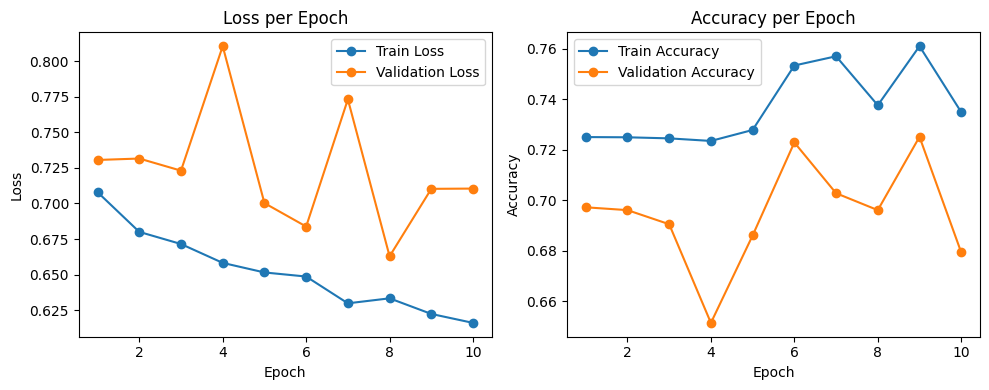

Final Training Accuracy: 0.7349
Final Validation Accuracy: 0.6793


In [ ]:
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.001, num_epochs=10)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def compute_confusion_matrix(model, data_loader, device, batch_size):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
      for imgs, labels in data_loader:
          imgs, labels = imgs.to(device), labels.to(device)
          preds = primarymodel(imgs).argmax(1)
          all_preds.extend(preds.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.show()

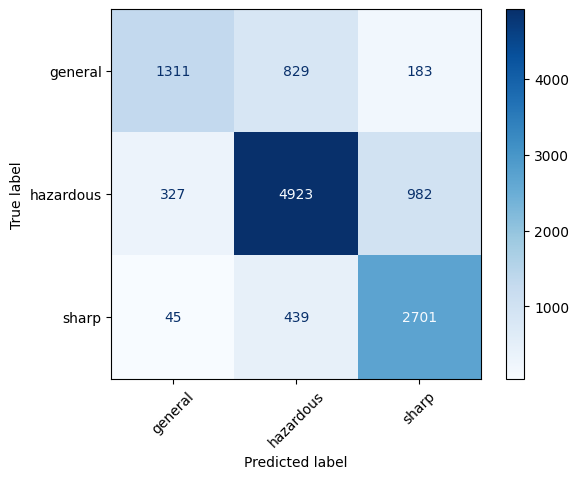

In [ ]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.001_epoch8"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)

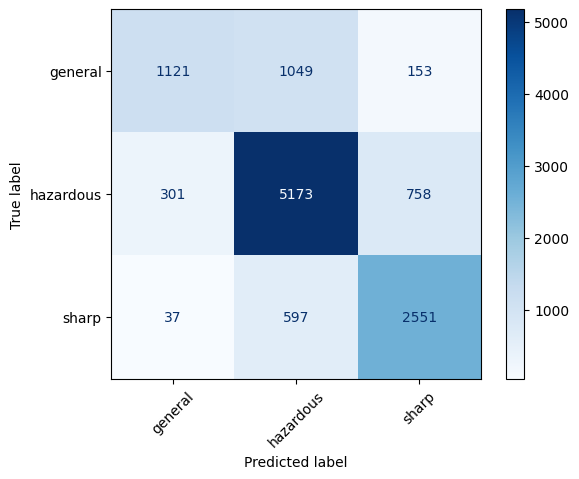

In [ ]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.001_epoch5"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)

In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/nonadapt_switchtoadapt_SGDtoAdam_bs64_lr0p001_epoch28.pth")

Model 2: adaptive class weights and medium learning rate only adam

Training on: cuda
Epoch [1/20] Train Loss: 0.9659 | Val Loss: 0.9669 | Train Acc: 0.5821 | Val Acc: 0.5721
Epoch [2/20] Train Loss: 0.8966 | Val Loss: 0.9301 | Train Acc: 0.5987 | Val Acc: 0.6045
Epoch [3/20] Train Loss: 0.8589 | Val Loss: 0.8684 | Train Acc: 0.6039 | Val Acc: 0.6011
Epoch [4/20] Train Loss: 0.8400 | Val Loss: 0.8511 | Train Acc: 0.6331 | Val Acc: 0.6212
Epoch [5/20] Train Loss: 0.8179 | Val Loss: 0.8424 | Train Acc: 0.6165 | Val Acc: 0.5777
Epoch [6/20] Train Loss: 0.7961 | Val Loss: 0.8738 | Train Acc: 0.6439 | Val Acc: 0.6358
Epoch [7/20] Train Loss: 0.7804 | Val Loss: 0.8080 | Train Acc: 0.6538 | Val Acc: 0.6447
Epoch [8/20] Train Loss: 0.7644 | Val Loss: 0.7898 | Train Acc: 0.6905 | Val Acc: 0.6704
Epoch [9/20] Train Loss: 0.7474 | Val Loss: 0.8006 | Train Acc: 0.6894 | Val Acc: 0.6782
Epoch [10/20] Train Loss: 0.7268 | Val Loss: 0.8399 | Train Acc: 0.6676 | Val Acc: 0.6156
Epoch [11/20] Train Loss: 0.7113 | Val Loss: 0.7828 | Train Acc: 0.6923 | Val Acc: 0.6816
E

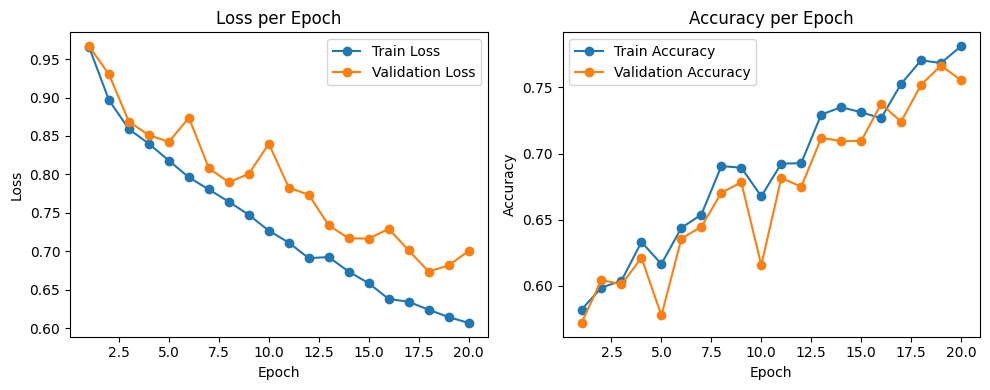

Final Training Accuracy: 0.7811
Final Validation Accuracy: 0.7553


In [ ]:
primarymodel = Primary_Model(kernel_size=3)
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.005, num_epochs=20)

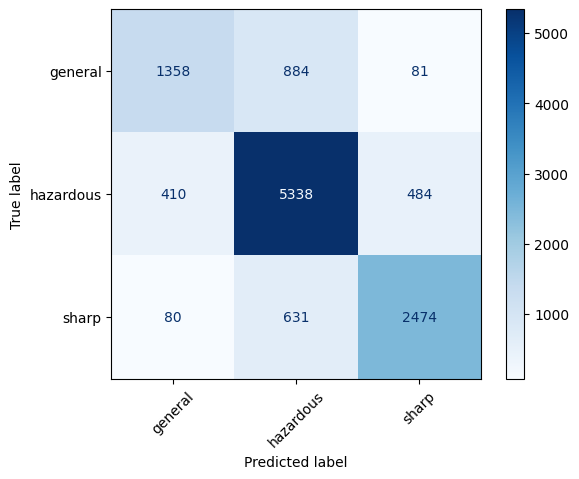

In [ ]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.005_epoch19"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)

In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/adaptweights_bs64_lr0p005_epoch19.pth")

Training on: cuda
Epoch [1/20] Train Loss: 0.5939 | Val Loss: 0.6647 | Train Acc: 0.7880 | Val Acc: 0.7620
Epoch [2/20] Train Loss: 0.5686 | Val Loss: 0.6756 | Train Acc: 0.8015 | Val Acc: 0.7732
Epoch [3/20] Train Loss: 0.5648 | Val Loss: 0.6313 | Train Acc: 0.8119 | Val Acc: 0.7777
Epoch [4/20] Train Loss: 0.5516 | Val Loss: 0.6842 | Train Acc: 0.7711 | Val Acc: 0.7754
Epoch [5/20] Train Loss: 0.5469 | Val Loss: 0.6411 | Train Acc: 0.8036 | Val Acc: 0.7732
Epoch [6/20] Train Loss: 0.5446 | Val Loss: 0.6475 | Train Acc: 0.8066 | Val Acc: 0.7531
Epoch [7/20] Train Loss: 0.5418 | Val Loss: 0.5638 | Train Acc: 0.8256 | Val Acc: 0.7877
Epoch [8/20] Train Loss: 0.5378 | Val Loss: 0.6067 | Train Acc: 0.8045 | Val Acc: 0.7520
Epoch [9/20] Train Loss: 0.5124 | Val Loss: 0.6750 | Train Acc: 0.8059 | Val Acc: 0.7609
Epoch [10/20] Train Loss: 0.5113 | Val Loss: 0.5731 | Train Acc: 0.8315 | Val Acc: 0.7698
Epoch [11/20] Train Loss: 0.5116 | Val Loss: 0.6451 | Train Acc: 0.8308 | Val Acc: 0.8011
E

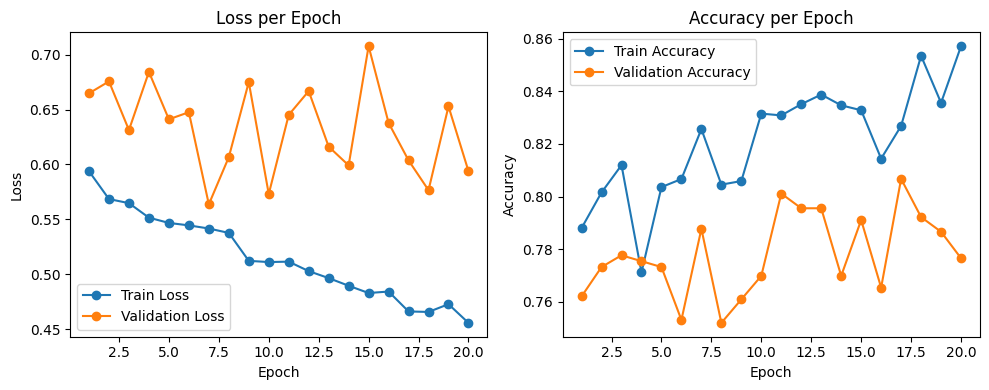

Final Training Accuracy: 0.8572
Final Validation Accuracy: 0.7765


In [ ]:
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.005, num_epochs=20)

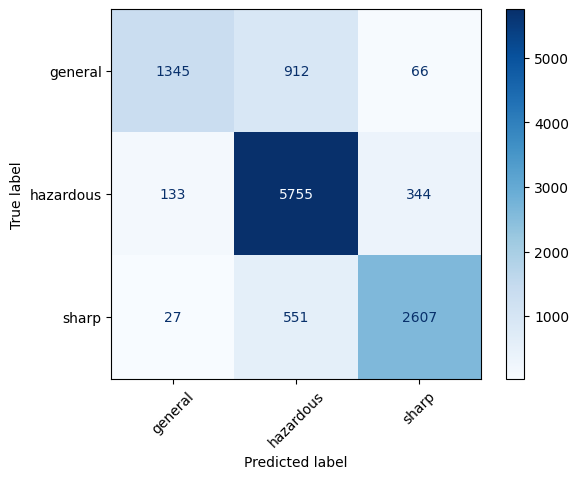

In [ ]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.005_epoch16"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)

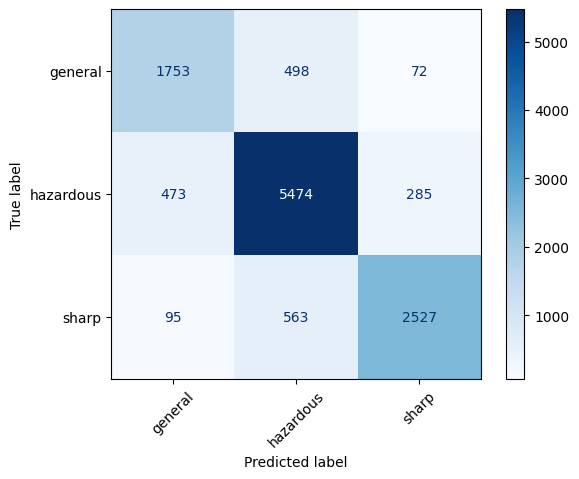

In [ ]:
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.005_epoch10"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)

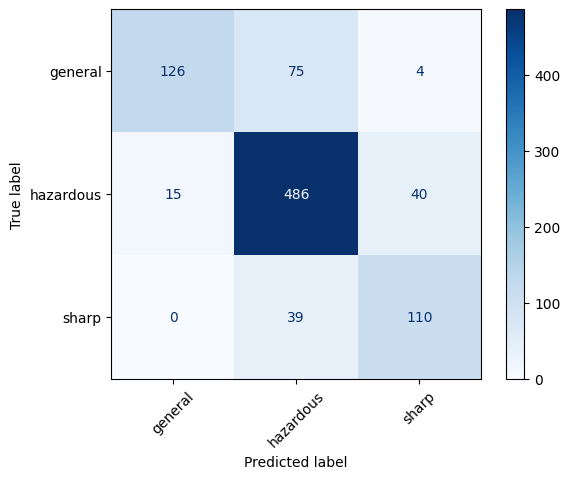

In [ ]:
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.005_epoch16"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
compute_confusion_matrix(primarymodel, val_loader, device, batch_size)

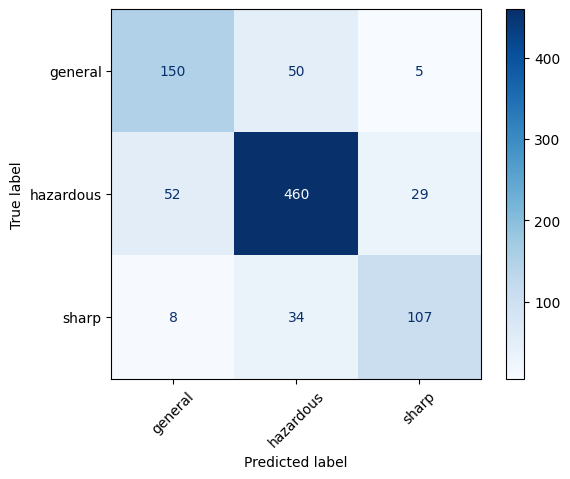

In [ ]:
primarymodel.load_state_dict(torch.load("/content/model_Primary_Model_bs64_lr0.005_epoch10"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
compute_confusion_matrix(primarymodel, val_loader, device, batch_size)

In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/adaptweights_bs64_lr0p005_epoch30.pth")

In [ ]:
primarymodel = Primary_Model(kernel_size=3)
primarymodel.load_state_dict(torch.load("/content/drive/MyDrive/aps360_project_dataset/models/adaptweights_bs64_lr0p005_epoch30.pth"))

<All keys matched successfully>

In [ ]:
test_data = datasets.ImageFolder("/content/drive/MyDrive/aps360_project_dataset/test2", transform=transforms.ToTensor())
primarymodel.eval()
test_accuracy = get_accuracy(primarymodel, train_data, test_data)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")


Final Test Accuracy: 0.5393


# Training Ver 2: early stopping and learning rate scheduling

In [ ]:
# @title
def train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = model.to(device)
    counts = torch.tensor([num_general, num_hazardous, num_sharp], dtype=torch.float)

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)  # Don't shuffle validation

    # Adaptive class weights
    beta = 0.999
    effective_num = 1.0 - beta**counts
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * len(counts)

    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)  # AdamW with weight decay

    # Learning rate scheduler - reduces LR when validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )

    # Early stopping parameters
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience = 7
    patience_counter = 0
    best_epoch = 0

    val_epoch_losses = []
    val_acc = []
    epoch_losses = []
    train_acc = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                val_running_loss += loss.item() * imgs.size(0)

            train_accuracy = get_accuracy(model, train_data, val_data, train=True)
            val_accuracy = get_accuracy(model, train_data, val_data, train=False)

        val_avg_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_losses.append(val_avg_loss)
        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        # Learning rate scheduling
        scheduler.step(val_avg_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Save checkpoint every epoch
        model_path = get_model_name("Primary_Model", batch_size, learning_rate, epoch)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_loss,
            'val_loss': val_avg_loss,
            'train_acc': train_accuracy,
            'val_acc': val_accuracy,
        }, model_path)

        # Early stopping check (based on validation loss)
        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            best_val_acc = val_accuracy
            best_epoch = epoch
            patience_counter = 0
            # Save best model separately
            best_model_path = get_model_name("Primary_Model_BEST", batch_size, learning_rate, 0)
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved. (Val Loss: {val_avg_loss:.4f})")
        else:
            patience_counter += 1

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_loss:.4f} | "
              f"Val Loss: {val_avg_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | "
              f"Val Acc: {val_accuracy:.4f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")

        # Early stopping trigger
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best model was at epoch {best_epoch+1} with val_loss: {best_val_loss:.4f}, val_acc: {best_val_acc:.4f}")
            break

    # --- Plotting Section ---
    epochs = range(1, len(epoch_losses) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Loss per Epoch")
    plt.plot(epochs, epoch_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_epoch_losses, marker='o', label="Validation Loss")
    plt.axvline(x=best_epoch+1, color='r', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.title("Accuracy per Epoch")
    plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
    plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
    plt.axvline(x=best_epoch+1, color='r', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Training Accuracy: {train_acc[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch+1})")

Training on: cuda
New best model saved. (Val Loss: 1.0249)
Epoch [1/20] Train Loss: 0.9625 | Val Loss: 1.0249 | Train Acc: 0.5560 | Val Acc: 0.5955 | LR: 0.005000 | Patience: 0/7
Epoch [2/20] Train Loss: 0.8851 | Val Loss: 1.1994 | Train Acc: 0.5171 | Val Acc: 0.4469 | LR: 0.005000 | Patience: 1/7
Epoch [3/20] Train Loss: 0.8523 | Val Loss: 1.2601 | Train Acc: 0.4802 | Val Acc: 0.3966 | LR: 0.005000 | Patience: 2/7
Epoch [4/20] Train Loss: 0.8438 | Val Loss: 1.2258 | Train Acc: 0.5097 | Val Acc: 0.4257 | LR: 0.005000 | Patience: 3/7
New best model saved. (Val Loss: 0.9308)
Epoch [5/20] Train Loss: 0.8208 | Val Loss: 0.9308 | Train Acc: 0.5960 | Val Acc: 0.6078 | LR: 0.005000 | Patience: 0/7
New best model saved. (Val Loss: 0.8288)
Epoch [6/20] Train Loss: 0.8110 | Val Loss: 0.8288 | Train Acc: 0.5752 | Val Acc: 0.6078 | LR: 0.005000 | Patience: 0/7
New best model saved. (Val Loss: 0.7895)
Epoch [7/20] Train Loss: 0.7970 | Val Loss: 0.7895 | Train Acc: 0.6348 | Val Acc: 0.6425 | LR: 0.0

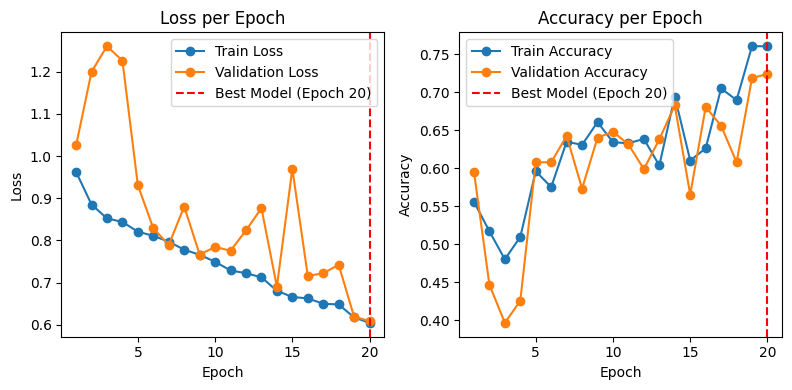


Final Training Accuracy: 0.7603
Final Validation Accuracy: 0.7240
Best Validation Accuracy: 0.7240 (Epoch 20)


In [ ]:
primarymodel = Primary_Model(kernel_size=3)
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.005, num_epochs=20)

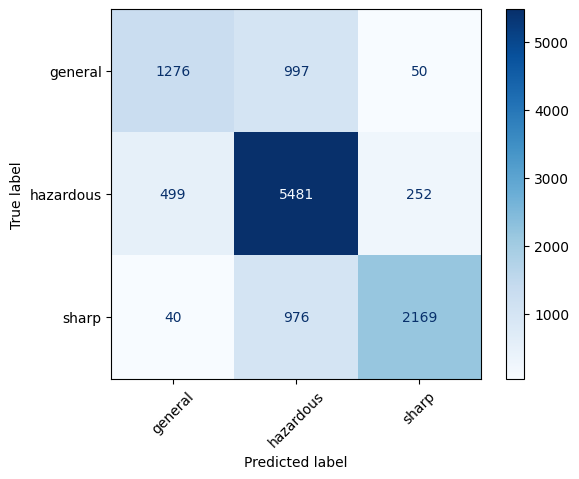

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, train_loader, device, batch_size)


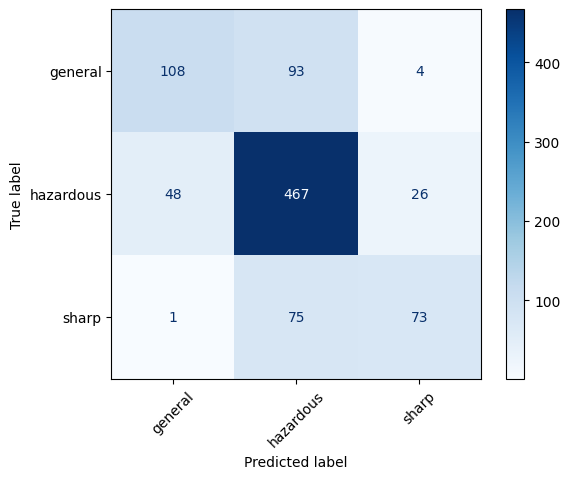

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compute_confusion_matrix(primarymodel, val_loader, device, batch_size)


In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/sche_le_earlystop_bs64_lr0p005to0p00125_epoch20.pth")

# Primary Model 2

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Primary_Model(nn.Module):
    def __init__(self, name="Primary_Model", kernel_size=3):
        super(Primary_Model, self).__init__()
        self.name = name

        self.features = nn.Sequential(
          # Block 1: 3 -> 48
          nn.Conv2d(3, 48, kernel_size=3, padding=1),
          nn.BatchNorm2d(48),
          nn.ReLU(inplace=True),
          nn.Conv2d(48, 48, kernel_size=3, padding=1),
          nn.BatchNorm2d(48),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.1),

          # Block 2: 48 -> 96
          nn.Conv2d(48, 96, kernel_size=3, padding=1),
          nn.BatchNorm2d(96),
          nn.ReLU(inplace=True),
          nn.Conv2d(96, 96, kernel_size=3, padding=1),
          nn.BatchNorm2d(96),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.15),

          # Block 3: 96 -> 192
          nn.Conv2d(96, 192, kernel_size=3, padding=1),
          nn.BatchNorm2d(192),
          nn.ReLU(inplace=True),
          nn.Conv2d(192, 192, kernel_size=3, padding=1),
          nn.BatchNorm2d(192),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(2, 2),
          nn.Dropout(0.2),
      )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(192, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(96, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

end of primary model 2

Training on: cuda
Epoch [1/20] Train Loss: 1.0043 | Val Loss: 0.9526 | Train Acc: 0.5489 | Val Acc: 0.5855
Epoch [2/20] Train Loss: 0.9155 | Val Loss: 0.9112 | Train Acc: 0.5831 | Val Acc: 0.5709
Epoch [3/20] Train Loss: 0.8672 | Val Loss: 0.9182 | Train Acc: 0.5852 | Val Acc: 0.5374
Epoch [4/20] Train Loss: 0.8540 | Val Loss: 0.8881 | Train Acc: 0.6102 | Val Acc: 0.5732
Epoch [5/20] Train Loss: 0.8232 | Val Loss: 0.9044 | Train Acc: 0.6246 | Val Acc: 0.5855
Epoch [6/20] Train Loss: 0.8019 | Val Loss: 0.8640 | Train Acc: 0.6543 | Val Acc: 0.6402
Epoch [7/20] Train Loss: 0.7723 | Val Loss: 0.8029 | Train Acc: 0.6807 | Val Acc: 0.6223
Epoch [8/20] Train Loss: 0.7580 | Val Loss: 0.8055 | Train Acc: 0.6842 | Val Acc: 0.6592
Epoch [9/20] Train Loss: 0.7246 | Val Loss: 0.7958 | Train Acc: 0.7017 | Val Acc: 0.6749
Epoch [10/20] Train Loss: 0.7057 | Val Loss: 0.7339 | Train Acc: 0.7381 | Val Acc: 0.6994
Epoch [11/20] Train Loss: 0.6924 | Val Loss: 0.7064 | Train Acc: 0.7182 | Val Acc: 0.7196
E

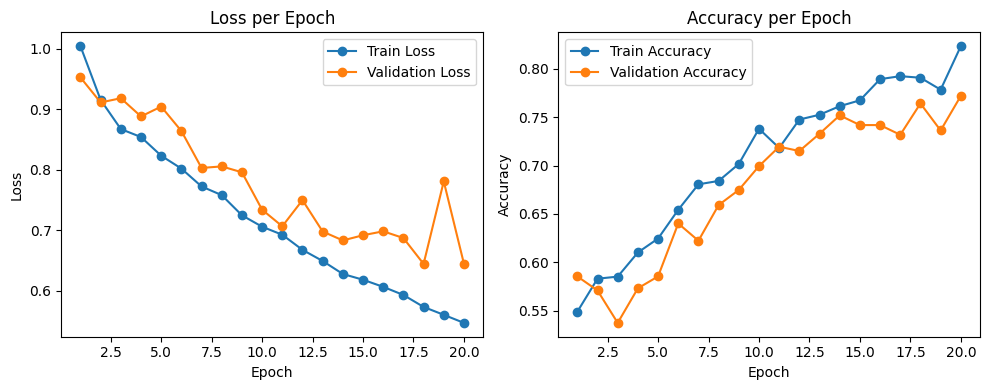

Final Training Accuracy: 0.8235
Final Validation Accuracy: 0.7721


In [ ]:
primarymodel = Primary_Model(kernel_size=3)
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=32, learning_rate=0.005, num_epochs=20)

In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/primarymodel2_bs32_lr0p005_epoch20.pth")

In [ ]:
primarymodel = Primary_Model(kernel_size=3)
primarymodel.load_state_dict(torch.load("/content/drive/MyDrive/aps360_project_dataset/models/primarymodel2_bs32_lr0p005_epoch20.pth"))

<All keys matched successfully>

In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/primarymodel2_bs32_lr0p005_epoch35.pth")

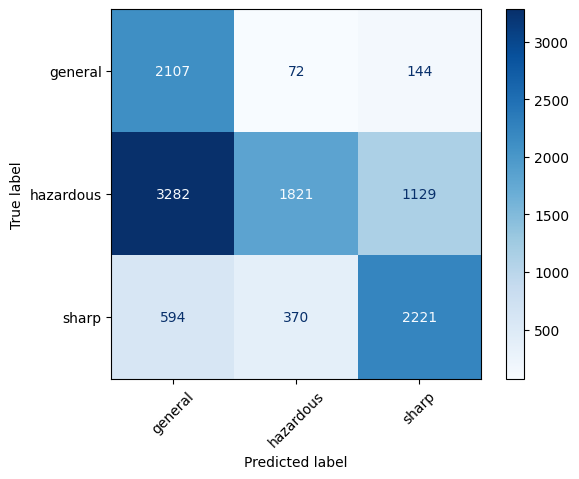

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# @title
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
primarymodel.eval()
with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = primarymodel(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

In [ ]:
primarymodelt = Primary_Model(kernel_size=3)
primarymodelt.load_state_dict(torch.load("/content/drive/MyDrive/aps360_project_dataset/models/model_SGD_WeightedLoss_bs64_lr0p001_epoch9.pth"))
primarymodelt.to("cuda")

Primary_Model(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (avgpool): AvgPool2d(kernel_size=28, stride=28, padding=0)
  (fc): Sequential(
    (0): Dropout(p=0.4, inplace=False)


In [ ]:
torch.save(primarymodel.state_dict(), "/content/drive/MyDrive/aps360_project_dataset/models/model_Adam_WeightedLoss_bs64_lr0p01_epoch9.pth")

Training on: cuda
Epoch [1/10] Loss: 0.7726 | Train Acc: 0.6110 | Val Acc: 0.5173
Epoch [2/10] Loss: 0.7583 | Train Acc: 0.6141 | Val Acc: 0.5196
Epoch [3/10] Loss: 0.7540 | Train Acc: 0.5811 | Val Acc: 0.5173
Epoch [4/10] Loss: 0.7492 | Train Acc: 0.6020 | Val Acc: 0.5352
Epoch [5/10] Loss: 0.7456 | Train Acc: 0.6252 | Val Acc: 0.5441
Epoch [6/10] Loss: 0.7408 | Train Acc: 0.6203 | Val Acc: 0.5486
Epoch [7/10] Loss: 0.7428 | Train Acc: 0.6147 | Val Acc: 0.5397
Epoch [8/10] Loss: 0.7437 | Train Acc: 0.6237 | Val Acc: 0.5397
Epoch [9/10] Loss: 0.7318 | Train Acc: 0.6230 | Val Acc: 0.5441
Epoch [10/10] Loss: 0.7332 | Train Acc: 0.5894 | Val Acc: 0.5240


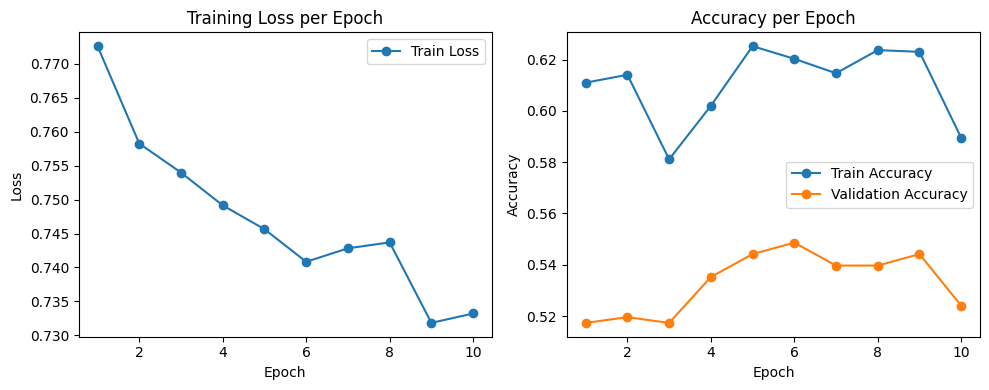

Final Training Accuracy: 0.5894
Final Validation Accuracy: 0.5240


In [ ]:
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.01, num_epochs=10)

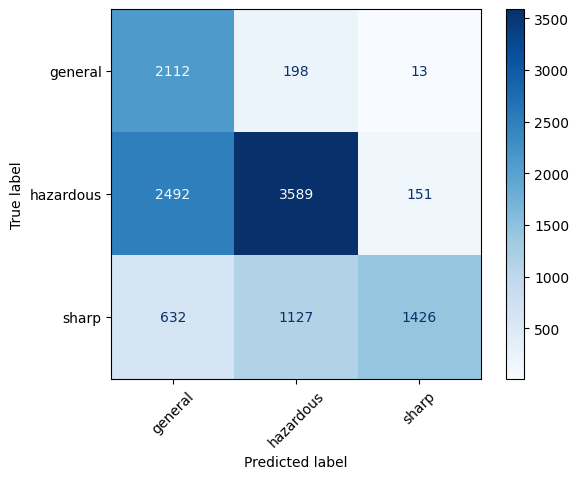

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# @title
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device

all_preds, all_labels = [], []
primarymodel.eval()
with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = primarymodel(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_data.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

Training on: cuda
Epoch [1/10] Loss: 0.7830 | Train Acc: 0.6009 | Val Acc: 0.5151
Epoch [2/10] Loss: 0.7736 | Train Acc: 0.5549 | Val Acc: 0.4793
Epoch [3/10] Loss: 0.7623 | Train Acc: 0.6010 | Val Acc: 0.5575
Epoch [4/10] Loss: 0.7421 | Train Acc: 0.5656 | Val Acc: 0.5084
Epoch [5/10] Loss: 0.7449 | Train Acc: 0.6546 | Val Acc: 0.5844
Epoch [6/10] Loss: 0.7164 | Train Acc: 0.4691 | Val Acc: 0.3609
Epoch [7/10] Loss: 0.7150 | Train Acc: 0.6007 | Val Acc: 0.5173
Epoch [8/10] Loss: 0.7206 | Train Acc: 0.5841 | Val Acc: 0.5486
Epoch [9/10] Loss: 0.7010 | Train Acc: 0.5992 | Val Acc: 0.5128
Epoch [10/10] Loss: 0.6957 | Train Acc: 0.6071 | Val Acc: 0.5698


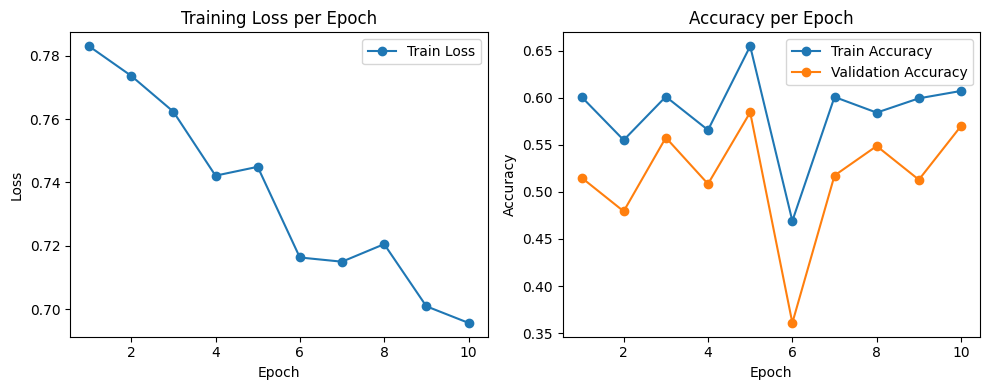

Final Training Accuracy: 0.6071
Final Validation Accuracy: 0.5698


In [ ]:
train(primarymodel, train_data=train_data, val_data=val_data, batch_size=64, learning_rate=0.01, num_epochs=10)